In [224]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Dataset 

In [225]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url,sep='\t',header=None,names=['label','message'])

extra_data = pd.read_csv('extra_dataset.csv')
print(extra_data.head())
print(extra_data.shape)
extra_data['label'] = 'spam'

# Combining 2 different datasets
df = pd.concat([df, extra_data], ignore_index=True)

(df.shape)

  label                                            message
0  spam  Your KYC is pending. Update now to avoid accou...
1  spam  Your UPI ID has been temporarily blocked. Clic...
2  spam  Urgent! Your bank account will be frozen in 24...
3  spam  Congratulations! You have won a ₹10,000 Amazon...
4  spam  Your electricity bill payment failed. Pay here...
(96, 2)


(5668, 2)

## 1. Data Cleaning

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5668 entries, 0 to 5667
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5668 non-null   object
 1   message  5668 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [227]:
# ENCODING
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [228]:
# Check for null values
df.isnull().sum()

label      0
message    0
dtype: int64

In [229]:
# Check for duplicates
df.duplicated().sum()

np.int64(403)

In [230]:
# Dropping duplicates
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [231]:
# Shape of the dataset changed as we have dropped duplicates
df.shape

(5265, 2)

## 2. EDA

In [232]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [233]:
df['label'].value_counts()

label
0    4516
1     749
Name: count, dtype: int64

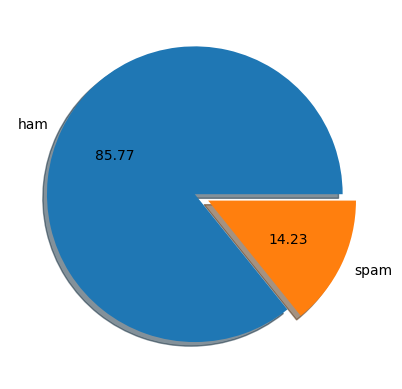

In [234]:
plt.pie(df['label'].value_counts(),explode=[0,0.1],shadow=True,labels=['ham','spam'],autopct="%0.2f")
plt.show()

Data is imbalance as we have few examples of spam in dataset

In [235]:
import nltk
nltk.download('punkt')  # Downloads the tokenizer models needed by NLTK to split text into sentences and words.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [236]:
# Getting total character length
df['Charcters_len'] = df['message'].apply(len)
df.head()

,label,message,Charcters_len
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [237]:
# Getting number of words in the message
df['num_words'] = df['message'].apply(lambda x : len(nltk.word_tokenize(x)))
df.head()

,label,message,Charcters_len,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [238]:
# Getting number of sentences in the message
df['Sentence_num'] = df['message'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.head()

,label,message,Charcters_len,num_words,Sentence_num
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [239]:
df[['Charcters_len','num_words','Sentence_num']].describe()

,Charcters_len,num_words,Sentence_num
count,5265.000000,5265.000000,5265.000000
mean,78.904843,18.450712,1.970560
std,58.009398,13.324463,1.447304
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,2.000000
75%,116.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [240]:
# Ham messages
df[df['label'] == 0][['Charcters_len','num_words','Sentence_num']].describe()

,Charcters_len,num_words,Sentence_num
count,4516.000000,4516.000000,4516.000000
mean,70.905890,17.267715,1.827724
std,56.715046,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [241]:
# Spam Messages
df[df['label'] == 1][['Charcters_len','num_words','Sentence_num']].describe()

,Charcters_len,num_words,Sentence_num
count,749.000000,749.000000,749.000000
mean,127.133511,25.583445,2.831776
std,39.376434,8.692768,1.462912
min,13.000000,2.000000,1.000000
25%,108.000000,21.000000,2.000000
50%,145.000000,28.000000,3.000000
75%,156.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='Charcters_len', ylabel='Count'>

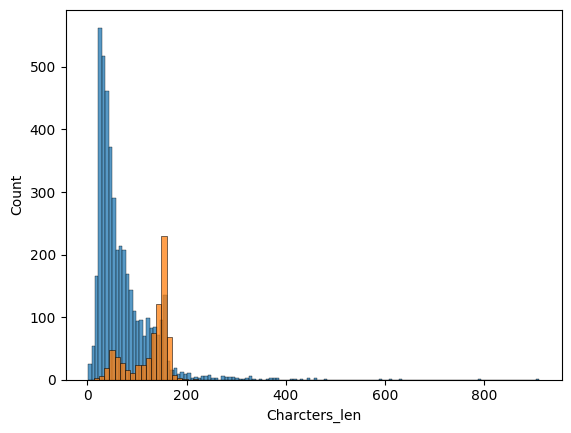

In [242]:
sns.histplot(df[df['label']==0]['Charcters_len'])
sns.histplot(df[df['label']==1]['Charcters_len'])

<Axes: >

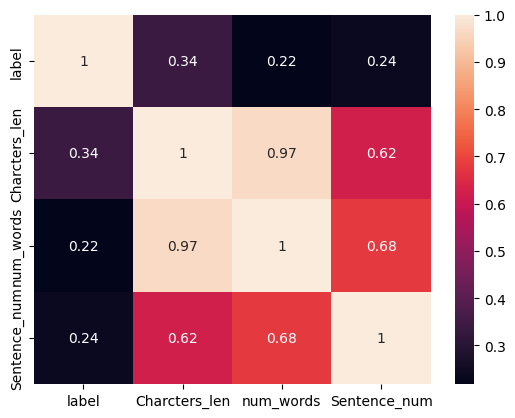

In [243]:
# compute correlation only for numeric columns to avoid trying to convert the text 'message' column to float
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

## 3. Data Preprocessing

In [244]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [245]:
from nltk.corpus import stopwords  # Importing stopwords
import string

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [246]:
df['tranformed_msg'] = df['message'].apply(transform_text)

In [247]:
df.head()

,label,message,Charcters_len,num_words,Sentence_num,tranformed_msg
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [248]:
from wordcloud import WordCloud
wc = WordCloud(width=700,height=700,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['label']==1]['tranformed_msg'].str.cat(sep=" "))

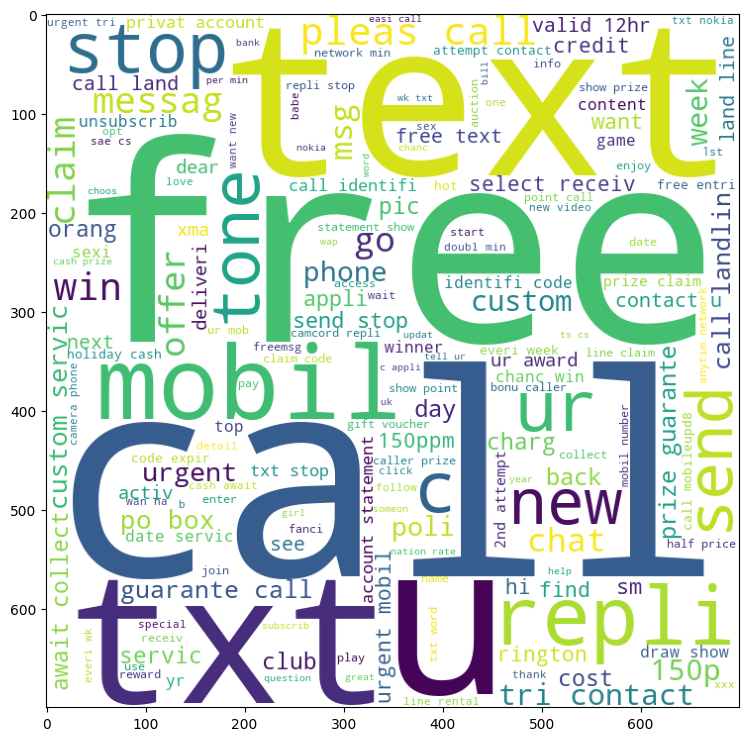

In [249]:
plt.figure(figsize=(15,9))
plt.imshow(spam_wc)

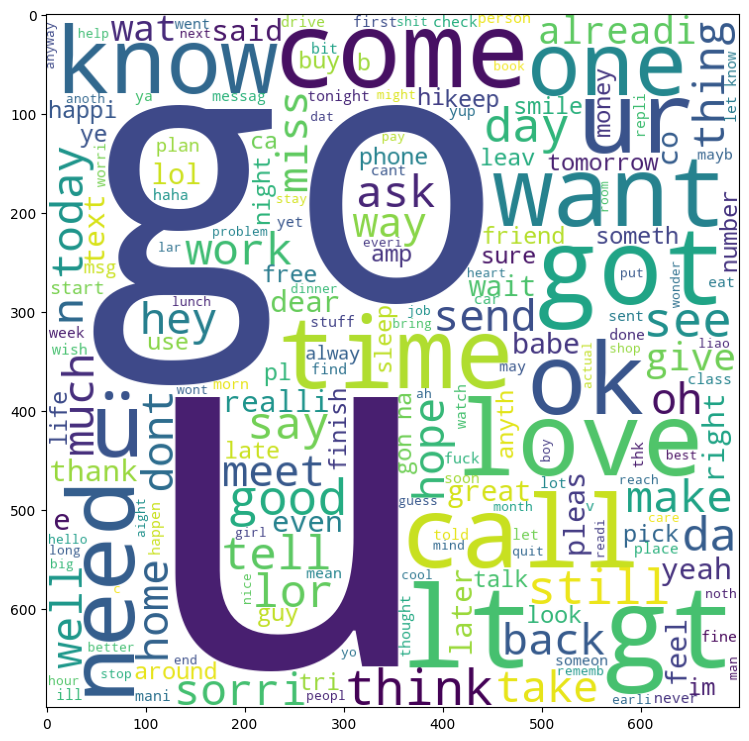

In [250]:
ham_wc = wc.generate(df[df['label']==0]['tranformed_msg'].str.cat(sep=" "))
plt.figure(figsize=(15,9))
plt.imshow(spam_wc)


In [251]:
df.head()

,label,message,Charcters_len,num_words,Sentence_num,tranformed_msg
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [252]:
spam_words = []
for msg in df[df['label'] == 1]['tranformed_msg'].tolist():
    for word in msg.split():
        spam_words.append(word)
len(spam_words)

10514

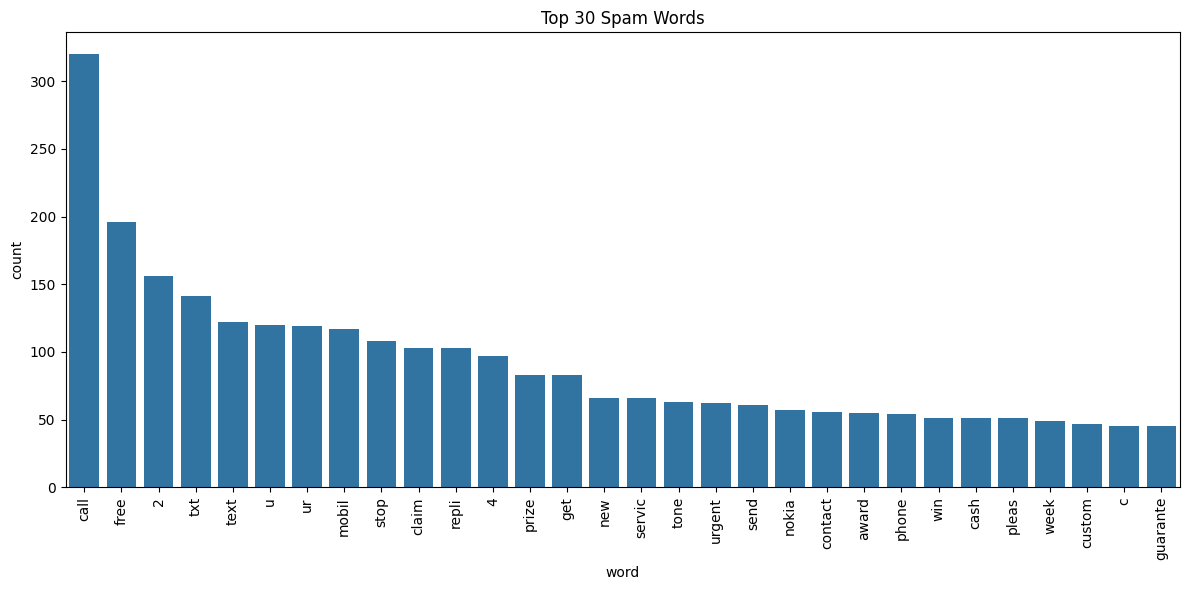

In [253]:
from collections import Counter

# prepare a dataframe of the top 30 words and their counts
counter_df = pd.DataFrame(Counter(spam_words).most_common(30), columns=['word', 'count'])

# plot using keyword arguments (some seaborn versions require x= and y=)
plt.figure(figsize=(12,6))
sns.barplot(x='word', y='count', data=counter_df)
plt.xticks(rotation=90)
plt.title('Top 30 Spam Words')
plt.tight_layout()
plt.show()

In [254]:
ham_words = []
for msg in df[df['label'] == 0]['tranformed_msg'].tolist():
    for word in msg.split():
        ham_words.append(word)
len(ham_words)

35939

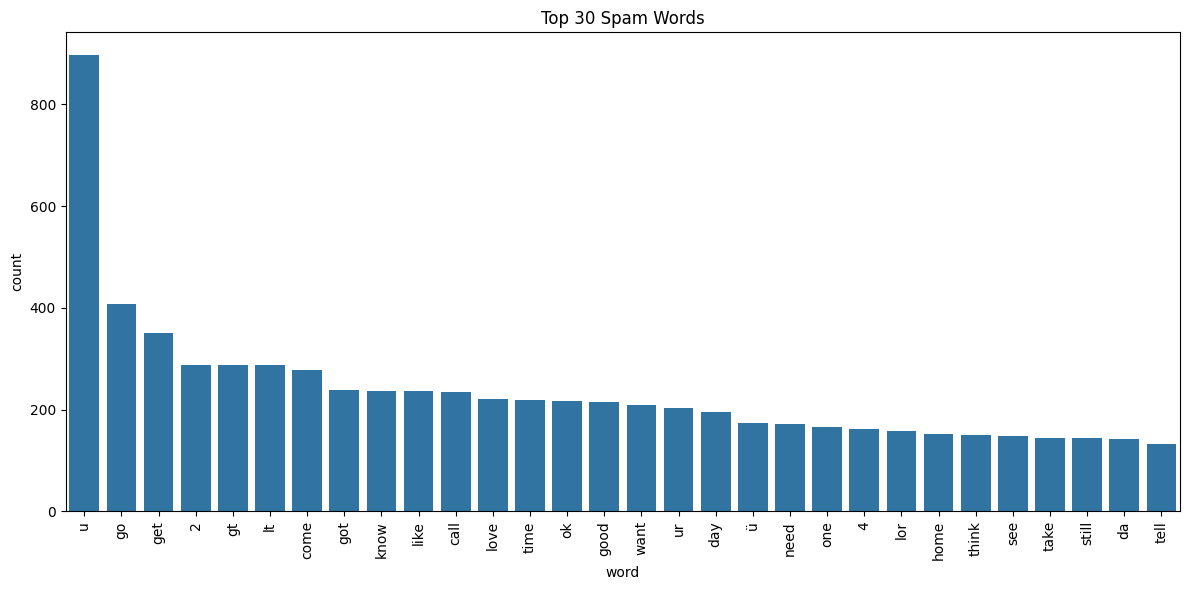

In [255]:
from collections import Counter

# prepare a dataframe of the top 30 words and their counts
counter_df = pd.DataFrame(Counter(ham_words).most_common(30), columns=['word', 'count'])

# plot using keyword arguments (some seaborn versions require x= and y=)
plt.figure(figsize=(12,6))
sns.barplot(x='word', y='count', data=counter_df)
plt.xticks(rotation=90)
plt.title('Top 30 Spam Words')
plt.tight_layout()
plt.show()

## 4. Model Building

In [256]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfid = TfidfVectorizer(max_features=4500)
cv = CountVectorizer()

In [257]:
X = tfid.fit_transform(df['tranformed_msg']).toarray()
print(f"X shape: {X.shape}")
y = df['label'].values

X shape: (5265, 4500)


In [258]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [259]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB() 

In [260]:
gnb.fit(X_train,Y_train)
gauss_pred = gnb.predict(X_test)
print(f"Accuracy score: {accuracy_score(Y_test,gauss_pred)}")
print(f"classification_report: {classification_report(Y_test,gauss_pred)}")
print(f"precision_score: {precision_score(Y_test,gauss_pred)}")

Accuracy score: 0.8414055080721747
classification_report:               precision    recall  f1-score   support

           0       0.97      0.84      0.90       900
           1       0.47      0.83      0.60       153

    accuracy                           0.84      1053
   macro avg       0.72      0.84      0.75      1053
weighted avg       0.90      0.84      0.86      1053

precision_score: 0.47388059701492535


In [261]:
mnb.fit(X_train,Y_train)
multi_pred = mnb.predict(X_test)
print(f"Accuracy score: {accuracy_score(Y_test,multi_pred)}")
print(f"classification_report: {classification_report(Y_test,multi_pred)}")
print(f"precision_score: {precision_score(Y_test,multi_pred)}")

Accuracy score: 0.9667616334283001
classification_report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98       900
           1       1.00      0.77      0.87       153

    accuracy                           0.97      1053
   macro avg       0.98      0.89      0.93      1053
weighted avg       0.97      0.97      0.96      1053

precision_score: 1.0


In [262]:
bnb.fit(X_train,Y_train)
bino_pred = bnb.predict(X_test)
print(f"Accuracy score: {accuracy_score(Y_test,bino_pred)}")
print(f"classification_report: {classification_report(Y_test,bino_pred)}")
print(f"precision_score: {precision_score(Y_test,bino_pred)}")

Accuracy score: 0.9686609686609686
classification_report:               precision    recall  f1-score   support

           0       0.97      1.00      0.98       900
           1       0.98      0.80      0.88       153

    accuracy                           0.97      1053
   macro avg       0.97      0.90      0.93      1053
weighted avg       0.97      0.97      0.97      1053

precision_score: 0.9761904761904762


Since from the above 3, Multinomial Bayes has the best metrics we will choose it as our main model

In [263]:
import pickle
pickle.dump(tfid,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))